In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45, Heun

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)
from schmitt_tdvp_randomized_blur import TDVPSchmittRandomizedBlur
from logger import Logger

∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

In [4]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn
from gaussian_state import make_epsilon_model
from dressed_rbm import DressedRBM

N = 32
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
alpha = 1
correlation = 1.0

def get_vstate(n_samples):
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    graph = nk.graph.Chain(N, pbc=True)
    # model = make_epsilon_model(s0_tuple=[-1] * N)
    rbm_model = nk.models.RBMSymm(
        alpha=alpha,
        param_dtype=complex,
        use_visible_bias=False,
        hidden_bias_init=nn.initializers.normal(1e-3),
        visible_bias_init=nn.initializers.normal(1e-3),
        kernel_init=nn.initializers.normal(1e-3),
        symmetries=graph.translation_group()
    )
    model = DressedRBM(rbm=rbm_model, amp_init=1e-5 * 2.**(-N/2.), correlation = correlation)
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100, n_discard_per_chain=5
    )
    vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array([[-1] * N]*n_samples, dtype =jnp.int8))
    # Thermalize
    for i in range(10):
        vstate.sample(n_samples=n_samples)
    return vstate


vstate = get_vstate(2**9)
print("Single peak state")

Single peak state


In [5]:
graph = nk.graph.Chain(N, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=-1.)
n_samples_list = [2**i for i in range(9,15)]

for i in range(N):
    string = ["I"]*N
    string[i] = "Z"
    if i==0:
        sigma_zs=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
    else:
        sigma_zs+=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_zs)
    return True

# Exact dynamics

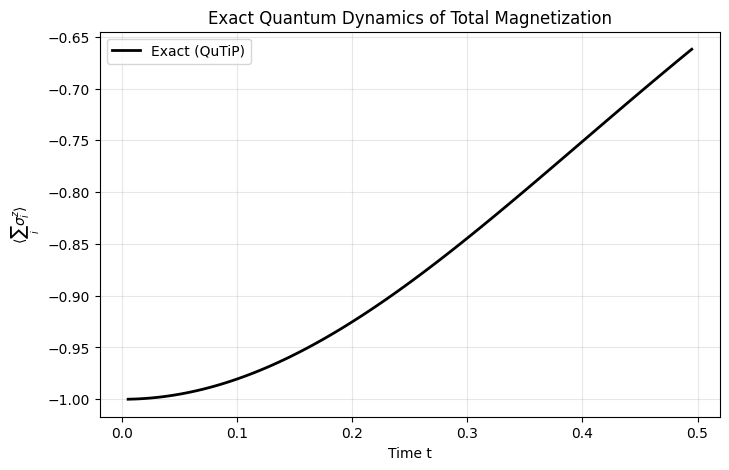

Initial magnetization: nan
Final magnetization: -0.662030


In [6]:
import qutip as qt

# Time evolution parameters
T = 0.5
J = 1.0
h = 1.0
times_exact = np.linspace(0.0, T, 100)
N = 32
if N <=4:
    # Get the Hamiltonian matrix from netket
    H_matrix = hamiltonian.to_dense()

    # Convert to QuTiP Qobj
    H_qutip = qt.Qobj(H_matrix)

    # Get initial state from vstate
    psi0_array = vstate.to_array()
    psi0_qutip = qt.Qobj(psi0_array)
    psi0_qutip = psi0_qutip.unit()  # Normalize

    # Create total magnetization operator (sum of Z_i)
    # Convert netket operator to matrix
    sigma_z_matrix = sigma_zs.to_dense() * N  # Multiply by N since sigma_zs is normalized by 1/N


    # Convert to QuTiP
    Z_total_qutip = qt.Qobj(sigma_z_matrix)

    # Evolve the state and calculate expectation values
    magnetizations_exact = []
    for t in times_exact:
        # Evolve state
        psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
        # Calculate expectation value
        mag = qt.expect(Z_total_qutip, psi_t)
        magnetizations_exact.append(mag / 4)
else:
    times_exact = np.load(f"data/TFIM_exact_Z/times_{N}_h{h:.2f}_J{J:.2f}_T{T:.2f}.npy")
    magnetizations_exact = np.load(f"data/TFIM_exact_Z/exactZ_{N}_h{h:.2f}_J{J:.2f}_T{T:.2f}.npy")

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

In [7]:

def fit_bridge(n_samples_tvmc, q1, q2):
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print("num of parameters:", vstate.n_parameters)
    print(vstate.expect(sigma_zs))
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    # integrator = RK45(1e-5, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    integrator = Heun(1e-3)
    tvmc_kwargs = {}
    driver = TDVPSchmittRandomizedBlur(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q1=q1,
        q2=q2,
        # flip_prob = 0.1,
        holomorphic=False,
        snr_atol=2.0,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)



In [8]:
for q1, q2 in [
               (0.2, 0.2), 
               (0.2, 1e-10),
               (1e-10, 1e-10),
               ]:
    for n_samples_tvmc in [2**10]:
        fit_bridge(n_samples_tvmc, q1=q1, q2=q2)

File not found
num of parameters: 65
-1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


  0%|          | 0.00/0.50 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 70.496                                                                                                   │
│ ├── (1.4%) | MCState.expect : 0.990 s                                                                           │
│ ├── (42.6%) | MCState.sample : 30.033 s                                                                         │
│ │   └── (80.2%) | sampling n_discarded samples : 24.100 s                                                       │
│ ├── (5.3%) | QGTJacobian_DefaultConstructor : 3.768 s                                                           │
│ │   └── (66.9%) | jacobian : 2.522 s                                                                            │
│ └── (12.2%) | _impl : 8.590 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

  0%|          | 0.00/0.50 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 67.122                                                                                                   │
│ ├── (1.5%) | MCState.expect : 1.001 s                                                                           │
│ ├── (45.9%) | MCState.sample : 30.822 s                                                                         │
│ │   └── (80.4%) | sampling n_discarded samples : 24.776 s                                                       │
│ ├── (5.8%) | QGTJacobian_DefaultConstructor : 3.880 s                                                           │
│ │   └── (69.3%) | jacobian : 2.689 s                                                                            │
│ └── (10.8%) | _impl : 7.275 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

  0%|          | 0.00/0.50 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 63.897                                                                                                   │
│ ├── (1.6%) | MCState.expect : 0.999 s                                                                           │
│ ├── (44.9%) | MCState.sample : 28.658 s                                                                         │
│ │   └── (80.4%) | sampling n_discarded samples : 23.028 s                                                       │
│ ├── (5.7%) | QGTJacobian_DefaultConstructor : 3.666 s                                                           │
│ │   └── (68.2%) | jacobian : 2.501 s                                                                            │
│ └── (10.9%) | _impl : 6.995 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.00_q2_0.00_T_0.50_alpha_1_correlation_0.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.20_T_0.50_alpha_1_correlation_0.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.00_T_0.50_alpha_1_correlation_0.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.00_q2_0.00_T_0.50_alpha_1_correlation_1.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.20_T_0.50_alpha_1_correlation_1.00/
Restored:
./data/TFIM_EPS_32/bridge_4096_rbm_q1_0.20_q2_0.00_T_0.50_alpha_1_correlation_1.00/
Restored:


/mnt/home/zwan1/venvs/nqs_bridge_sampling/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/zwan1/venvs/nqs_bridge_sampling/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


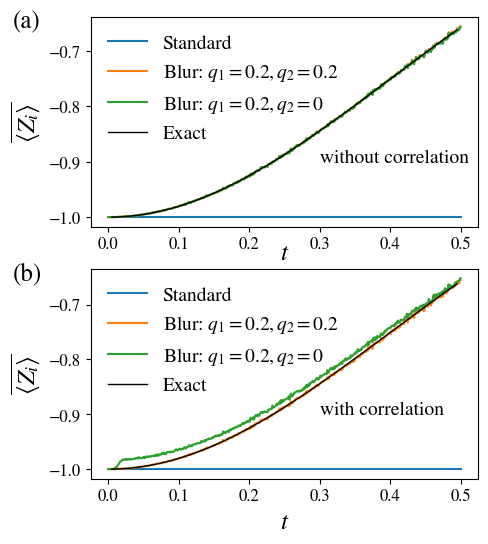

In [36]:

import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

fig, axes = plt.subplots(2, 1, figsize=(5, 6))
ax_1, ax_2 = axes
N = 32
T = 0.5
alpha = 1
correlation = 0.0
for q1, q2 in [(0.0,0.0),
               (0.2, 0.2), 
               (0.2, 0.0),
               ]:
    for n_samples in [2**12]:
        exp_name = f"bridge_{n_samples}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
        save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
        print(save_path)
        logger = Logger(path=save_path, fields=fields_to_track)
        if q1 == 0.0 and q2 == 0.0:
            label = f"Standard"
        elif q2 == 0.0:
            label = rf"Blur: $q_1={q1}, q_2=0$"
        else:
            label = rf"Blur: $q_1={q1}, q_2={q2}$"
        if logger.restore():
            print("Restored:")
            ax_1.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = label, zorder=-1)
ax_1.set_xlabel("t")
ax_1.plot(times_exact[times_exact<0.5], np.real(magnetizations_exact)[times_exact<0.5], 'k-', linewidth=1, label='Exact')


correlation = 1.0

for q1, q2 in [(0.0,0.0),
               (0.2, 0.2), 
               (0.2, 0.0),
               ]:
    for n_samples in [2**12]:
        exp_name = f"bridge_{n_samples}_rbm_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}_alpha_{alpha}_correlation_{correlation:.2f}"
        save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
        print(save_path)
        logger = Logger(path=save_path, fields=fields_to_track)
        if q1 == 0.0 and q2 == 0.0:
            label = f"Standard"
        elif q2 == 0.0:
            label = rf"Blur: $q_1={q1}, q_2=0$"
        else:
            label = rf"Blur: $q_1={q1}, q_2={q2}$"
        if logger.restore():
            print("Restored:")
            ax_2.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = label, zorder=-1)
ax_2.plot(times_exact[times_exact<0.5], np.real(magnetizations_exact)[times_exact<0.5], 'k-', linewidth=1, label='Exact')


ax_1.legend(frameon = False, fontsize = 14)
ax_2.legend(frameon = False, fontsize = 14)
ax_2.set_xlabel(r"$t$", fontsize = 18)
ax_1.set_xlabel(r"$t$", fontsize = 18, labelpad=-8)

ax_1.text(0.3, -0.9, "without correlation", fontsize = 14)

ax_2.text(0.3, -0.9, "with correlation", fontsize = 14)

ax_1.set_ylabel(r"$\overline{\langle Z_i \rangle}$",fontsize = 18)
ax_2.set_ylabel(r"$\overline{\langle Z_i \rangle}$",fontsize = 18)

loc_x = -0.2
loc_y = 0.95
ax_1.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=18)
ax_2.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=18)
ax_1.tick_params(axis='both', which='major', labelsize=12)
ax_2.tick_params(axis='both', which='major', labelsize=12)
plt.savefig("Fig6.pdf", bbox_inches="tight", pad_inches=0.01)